# Sprint 5 - Análisis Exploratorio de Datos (Ejercicios)

En estos ejercicios se busca aplicar los conocimientos adquiridos de programación en **Python** para profundizar en 3 conceptos de estadística extremadamente útiles para **Análisis Exploratorio de Datos (EDA)** y el desarrollo de modelos predictivos: 

* Ley de los grandes números.
* Teorema del límite central.
* Pruebas de hipótesis.

## Ley de los grandes números

La Ley de los grandes números, establecida empíricamente por Cardano (1550) y demostrada formalmente por Jakob Bernoulli (1713), especifica que el estadístico $\bar\theta$ de una muestra de tamaño $n$ extraída de una población cualquiera, convergerá hacía el estadístico poblacional $\theta$ a medida que $n$ aumenta. En términos matemáticos si recurdas algo de límites esta definición sería así:

$$ \lim_{n\rightarrow \infty} \bar\theta = \theta $$

Consideremos por ejemplo al estadístico **media**, lo que nos dice esta ley es que el promedio de una parte (muestra) de un conjunto de datos (población), será similar al promedio de todo el conjunto siempre que esa parte sea suficientemente grande.

Vamos a probar esto con nuestros conocimientos de **Python**.

### Ejercicio 1

Importa la librería **random** y genera una lista con 2,000 valores aleatorios entre 0 y 100 utilizando un bucle y la función `randint` de esta librería. Guarda el resultado en la variable `poblacion`.

In [1]:
# Importar libreria
import random

# Generar datos aleatorios
poblacion = [random.randint(0,100) for i in range(2000)]

Calcula el promedio de esta población y guárdala en la variable `prom_poblacion`. Seguramente te sirve importar **numpy** para utilizar la función `mean`.

In [2]:
# Importar libreria
import numpy as np

# Calcular promedio
prom_poblacion = np.mean(poblacion)
print(prom_poblacion)

50.4985


Extrae una muestra aleatoria de tamaño 5 de tu población utilizando la función `sample` de la librería **random**. Guarda tu resultado en la variable `muestra`.

In [3]:
muestra = random.sample(poblacion, 5)
print(muestra)

[16, 77, 98, 83, 47]


Calcula el promedio de esta muestra y guárdala en una variable `prom_muestra`.

In [4]:
prom_muestra = np.mean(muestra)
print(prom_muestra)

64.2


Es posible que el promedio de la muestra obtenido no sea tan parecido al de la población. No te preocupes, usaremos la lógica de la ley de los grandes números para mejorar esta aproximación.

### Ejercicio 2

Crea una lista `promedios` que contenga cálculos del promedio de muestras de forma equivalente al realizado en el ejercicio anterior. Solamente que ahora considera como tamaño de las muestras valores que inicien en 5 y terminen en 1,500, con saltos de 5 unidades (es decir, 5, 10, 15, 20, 25, ..., 995, 1000, ..., 1495, 1500). 

In [5]:
promedios = []
for n in range(5,1505,5):
    muestra = random.sample(poblacion, n)
    promedios.append(np.mean(muestra))

Crea un dataframe con **pandas** que contenga dos columnas:

* La primera debe especificar los tamaños de muestra que utilizaste en el código anterior.
* La segunda debe especificar los valores guardados en tu lista `promedios`.

In [6]:
# Cargar libreria
import pandas as pd

# Generar dataframe
df_promedios = pd.DataFrame(dict(
    n = range(5,1505,5),
    promedio = promedios
))
df_promedios.head()

,n,promedio
0,5,57.00
1,10,49.00
2,15,54.00
3,20,49.60
4,25,62.36


Grafica de forma simple la evolución de los promedios obtenidos a medida que se incrementa el tamaño de la muestra. Incluye una linea horizontal en color rojo que muestre el promedio de la población.

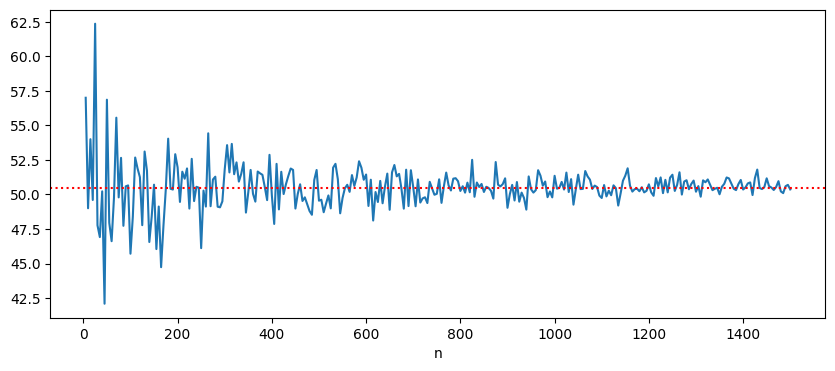

In [7]:
import matplotlib.pyplot as plt

df_promedios.plot(
    x = "n",
    y = "promedio",
    legend = None,
    figsize = [10,4]
)
plt.axhline(y = prom_poblacion, color = "red", linestyle = ":")
plt.show()

Si todo fue hecho correctamente hasta ahora, deberías evidenciar que el promedio de las muestras converge hacia el promedio de la población a medida que el tamaño de muestra aumenta. Justamente lo que indica la ley de los grandes números.

### Ejercicio 3

Intenta comprobar que esta ley igualmente se cumple para otros estadísticos como la desviación estandar. Puedes utilizar la función `np.std` para asistirte en tus cálculos.

In [8]:
# Calcular std de la poblacion
std_poblacion = np.std(poblacion)
print(std_poblacion)

29.32664313810907


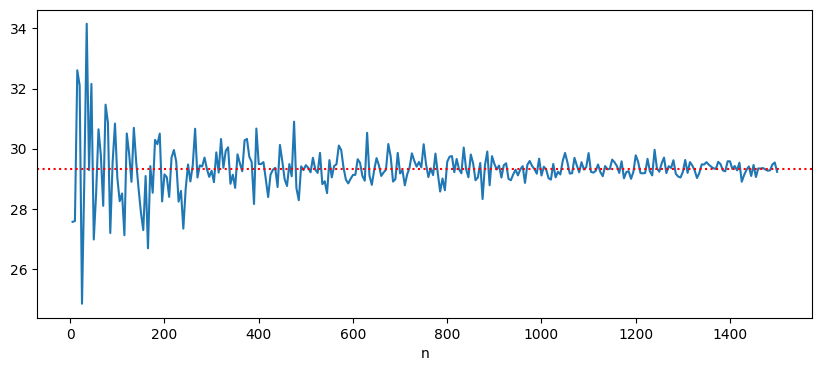

In [9]:
# Calcular std para distintos tamaños de muestra
desviaciones = []
for n in range(5,1505,5):
    muestra = random.sample(poblacion, n)
    desviaciones.append(np.std(muestra))

# Crear dataframe con desviaciones muestrales
df_desviaciones = pd.DataFrame(dict(
    n = range(5,1505,5),
    std = desviaciones
))

# Graficar evolución dedesviaciones
df_desviaciones.plot(
    x = "n",
    y = "std",
    legend = None,
    figsize = [10,4]
)
plt.axhline(y = std_poblacion, color = "red", linestyle = ":")
plt.show()

Como puedes observar, la ley de los grandes números es una de las muchas razones por las cuales a los analistas y científicos de datos nos gustan las tablas "grandes" en lo que respecta a cantidad de observaciones. Mientras más...¡mejor!

## Teorema del límite central

El Teorema del límite central se constituye en una herramienta central de todo análisis basado en estadística, pues especifica que la distribución del promedio de una muestra aleatoria extraída de una población, tenderá a ser *Normal* a medida que el tamaño de muestra $n$ se incrementa. Además esta distribución tendrá los siguientes parámetros:

* Centralidad en la media de la población.
* Error estandar $s = \sigma/\sqrt{n}$, donde $\sigma$ corresponde a la desviación estandar poblacional.

En términos más "casuales" aunque no tan precisos, este teorema nos dice que el promedio de cualquier variable sigue una distribución en forma de campana si se cuenta con la suficiente cantidad de observaciones.

El teorema fue planteado ya en 1733 por de Moivre, con las primeras formalizaciones a principios del siglo XIX gracias a las investigaciones de Laplace y Gauss. Su demostración más moderna y formal llegaría un siglo más tarde gracias al trabajo de Lyapunov. Vamos ahora a verificarlo con nuestros conocimientos de **Python**.

### Ejercicio 1

Simula el lanzamiento de un dado común utilizando nuevamente la función `randint`. Por si necesitas saberlo un dado común es aquel que tiene 6 caras y que al lanzarlo cada cara tiene igual probabilidad de salir, esto es, una entre seis posibilidades.

In [10]:
random.randint(1,6)

1

Imagina ahora que lanzas el dado 50 veces. Guarda los resultados obtenidos en una lista llamada `lanzamientos`. 

In [11]:
lanzamientos = [random.randint(1,6) for i in range(50)]
print(lanzamientos)

[1, 1, 3, 6, 6, 3, 3, 2, 5, 2, 4, 1, 3, 2, 1, 5, 4, 1, 4, 5, 2, 1, 6, 2, 3, 4, 2, 4, 1, 6, 2, 1, 1, 6, 5, 2, 2, 1, 1, 2, 6, 6, 3, 4, 2, 6, 3, 1, 5, 5]


Calcula el promedio de tus lanzamientos y guarda el resultado en la variable `prom_lanzamientos`.

In [12]:
prom_lanzamientos = np.mean(lanzamientos)
print(prom_lanzamientos)

3.14


Si has hecho todo bien hasta ahora, el promedio obtenido debería ser un valor cercano a $3.5$. ¿Podrías intuir por qué este valor?

### Ejercicio 2

Repite 10 veces este experimento de lanzar 50 dados. Guarda el promedio de cada una de estas iteraciones en una variable llamada `promedios`. 

**NOTA:** Vale señalar que para efectos de asimilar lo solicitado con la definición del Teorema del límite central, nuestro tamaño de muestra $n$ sería 10.  

In [13]:
promedios = []
for i in range(10):
    lanzamientos = [random.randint(1,6) for i in range(50)]
    prom_lanzamientos = np.mean(lanzamientos)
    promedios.append(prom_lanzamientos)

print(promedios)

[np.float64(3.22), np.float64(3.08), np.float64(3.42), np.float64(4.0), np.float64(3.5), np.float64(3.36), np.float64(3.14), np.float64(3.68), np.float64(3.7), np.float64(3.76)]


Grafica estos resultados en un histograma simple que tenga aproximadamente $\sqrt{n}$ barras. Recuerda que en este caso $n$ sería 10. 

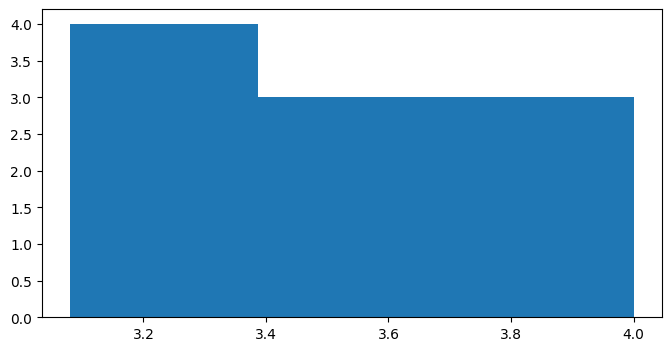

In [14]:
plt.figure(figsize = [8,4])
plt.hist(promedios, bins = int(np.sqrt(10)))
plt.show()

El gráfico no parece sugerir que este promedio siga una distribución *Normal*. No te preocupes, vamos a llegar a ello con el Teorema del límite central.

### Ejercicio 3

Define la funcion `tlc` que automatice el proceso del ejercicio anterior, tomando como entrada un valor de lanzamientos $n$ y devolviendo un histograma con aproximadamente $\sqrt{n}$ barras. 

In [15]:
def tlc (n):
    
    # Iterar n veces
    promedios = []
    for i in range(n):
        lanzamientos = [random.randint(1,6) for i in range(50)]
        prom_lanzamientos = np.mean(lanzamientos)
        promedios.append(prom_lanzamientos)
    
    # Histograma de las iteraciones
    plt.figure(figsize = [8,4])
    plt.hist(promedios, bins = int(np.sqrt(n)))
    plt.show()

Utiliza tu función `tlc` para ver la distribución resultante en un tamaño de muestra $n$ de 100.

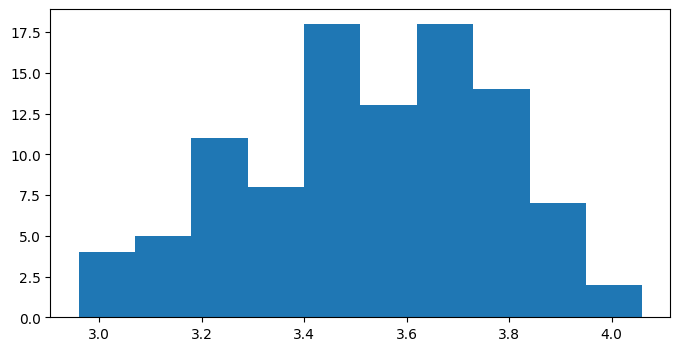

In [16]:
tlc(100)

Repite el ejercicio con tamaños de muestra de 1,000 y 10,000.

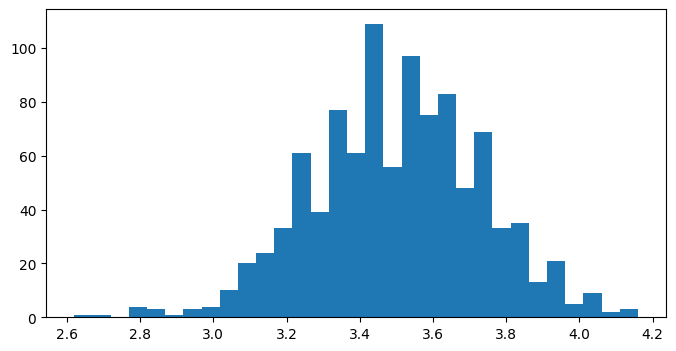

In [17]:
# Histograma con 1,000 experimentos
tlc(1000)

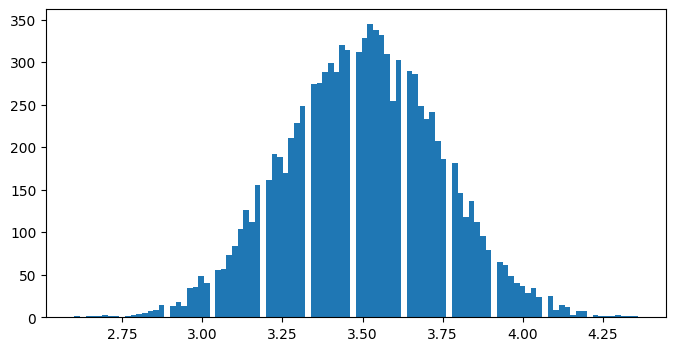

In [18]:
# histograma con 10,000 experimentos
tlc(10000)

Si todo se ha hecho correctamente, notarás que los últimos histogramas tienen una forma muy familiar: la de una distribución *Normal*. Justamente aquella predicha por el Teorema del limite central.

Seguramente te preguntarás cuál es la utilidad de este resultado en tu aprendizaje de ciencia de datos. Aquí algunas respuestas:

* En inferencia estadística, la existencia y decisión de uso de algunas pruebas de hipótesis (como las asociadas a medias), dependen exclusivamente de que se cumpla esta proposición. Es por este motivo que cuando el tamaño de muestra es pequeño, se sugiere el uso del test U de Mann-Whitney; no así cuando el tamaño de muestra es grande donde se usan las pruebas t que asumen que las medias siguen una distribución simétrica en forma de campana tal y como hace referencia este teorema. 
* La confiabilidad y robustez de muchos algoritmos que se utilizan en el modelamiento predictivo y aprendizaje computacional necesitan que las variables a predecir sigan una distribución normal. Por tanto, la agregación a valores promedio puede garantizar el cumplimiento de este requerimiento en específico.
* Pero ante todo, la distribución normal es bastante conocida y documentada, por lo que mantener variables que sigan esta distribución facilita su estudio y comprensión. No sucedería lo mismo si el comportamiento observado tendría propiedades menos "naturales" que exigirían mayor complejidad en nuestros análisis.

## Pruebas de hipótesis

Es usual que la ejecución de pruebas de hipótesis se vuelva mécanico y sin una comprensión clara de qué es lo que está sucediendo por detrás. Por tanto en estos ejercicios realizarás un test de hipótesis de medias de forma manual, es decir, prescindiendo de las funciones de **Scipy**.

### Ejercicio 1

Importa el dataset [**iris.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/iris.csv), que contiene información de características de pétalos y sépalos de 3 variedades de flores. 

In [19]:
df_iris = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/iris.csv")

Mira en más detalle este dataset para que te familiarices con su contenido y estructura.

In [20]:
# mostrar Estructura de los datos
df_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   type          150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [21]:
# Generar muestra aleatoria de los datos
df_iris.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,type
58,6.6,2.9,4.6,1.3,1
89,5.5,2.5,4.0,1.3,1
112,6.8,3.0,5.5,2.1,2
43,5.0,3.5,1.6,0.6,0
91,6.1,3.0,4.6,1.4,1
84,5.4,3.0,4.5,1.5,1
44,5.1,3.8,1.9,0.4,0
51,6.4,3.2,4.5,1.5,1
36,5.5,3.5,1.3,0.2,0
79,5.7,2.6,3.5,1.0,1


In [22]:
# Hacer un conteo de la columan type
df_iris["type"].value_counts()

type
0    50
1    50
2    50
Name: count, dtype: int64

### Ejercicio 2

Has un resumen estadístico de tu dataset, excluyendo a la columna type.

In [23]:
df_iris[["sepal_length","sepal_width","petal_length","petal_width"]].describe().round(1)

,sepal_length,sepal_width,petal_length,petal_width
count,150.0,150.0,150.0,150.0
mean,5.8,3.1,3.8,1.2
std,0.8,0.4,1.8,0.8
min,4.3,2.0,1.0,0.1
25%,5.1,2.8,1.6,0.3
50%,5.8,3.0,4.4,1.3
75%,6.4,3.3,5.1,1.8
max,7.9,4.4,6.9,2.5


Al parecer el promedio de petal_length es un poco menor a 4 unidades. Comprueba estadísticamente esta hipótesis con una significancia del 1% y utilizando la función `ttest_1samp` de la librería **Scipy**. Sé que te dije que no íbamos a utilizar estas funciones, pero solamente veamos los resultados para tener un punto de contraste.

**HIPOTESIS NULA Y ALTERNATIVA**

| Hipótesis | Postulado |
| ---- | ---- |
| Nula | El promedio de petal_length es IGUAL a 4. |
| Alternativa | El promedio de petal_length es MENOR a 4. |

In [24]:
# Cargar libreria
import scipy.stats as st

# Extraer muestras de cada tipo
muestra = df_iris["petal_length"]

# Generar prueba t
prueba_t = st.ttest_1samp(muestra, popmean = 4, alternative = "less")

# Extrer valor p y generar decisión
valor_p = prueba_t.pvalue

# Ejecutar criterio de decision
if valor_p < 0.01:
    print("Se rechaza H0: El promedio sería menor a 4")
else:
    print("No se rechaza H0: El promedio sería igual a 4")

No se rechaza H0: El promedio sería igual a 4


In [25]:
# Generar prueba t
prueba_t = st.ttest_1samp(muestra, popmean = 4, alternative = "less")
prueba_t

TtestResult(statistic=np.float64(-1.67896989467615), pvalue=np.float64(0.04762690318065021), df=np.int64(149))

Guarda también el "estadístico de prueba" en la variable `est`, y que lo puedes encontrar en el atributo `statistic`.

In [26]:
est = prueba_t.statistic

### Ejercicio 3

Ahora sí, vamos a entender cómo funciona esta prueba t paso a paso. En primer lugar, guarda el promedio de la columna petal_length en la variable `prom`.

In [27]:
prom = np.mean(muestra)
print(prom)

3.7580000000000005


Calcula el error estandar $s$ de este promedio y guarda el resultado en la variable `error`. Recuerda que de acuerdo al Teorema del liímite central se cumple que

$$ s = \frac{\sigma}{\sqrt{n}} $$

donde $\sigma$ es la desviación poblacional que la podemos **aproximar** mediante la desviación de la columna petal_length. 

Utiliza la función `np.std` e  incorpora el argumento `ddof = 1`. Esto es un ajuste importante dada la aproximación que estamos haciendo.

In [28]:
error = np.std(muestra, ddof = 1) / np.sqrt(len(muestra))
print(error)

0.14413599717741096


Estandariza la variable `prom` con centro en 4 y scala $s$ y guarda este resultado en la variable `prom_est`. Esto es, aplica la siguiente fórmula:

$$ prom_{est} = \frac{prom - 4}{error} $$

In [29]:
prom_est = (prom - 4) / error
print(prom_est)

-1.67896989467615


Si hiciste todo bien, el valor obtenido es el mismo que el estadístico de tu prueba t. Compruébalo ejecutando el siguiente código:

```py
print(prom_est == est)
```

In [30]:
print(prom_est == est)

True


El *valor p* está directamente asociado con este promedio estandarizado puesto que corresponde a la probabilidad acumulada (cdf) asociada a este valor. Utiliza de función `t.cdf` de **scipy** para verificarlo. En dicha función incorpora el argumento `df` con un valor igual a $n - 1$.

In [31]:
# Calcular el valor p manualmente
valor_p_calculado = st.t.cdf(prom_est, df = len(muestra) - 1)
print(valor_p_calculado)

0.04762690318065021


In [32]:
# Comprobar que el valor calculado es igual al obtenido en la prueba t
print(valor_p_calculado == valor_p)

True
